# Assignment: Xarray Fundamentals with Atmospheric Radiation Data

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/xg2467/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


## 1) Opening data and examining metadata

### 1.1) Open the dataset and display its contents

In [3]:
ds = xr.open_dataset(fname)
ds

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 1.2) Print out the `long_name` attribute of each variable

In [4]:
max_len = max(len(var) for var in ds.data_vars)
for var in ds.data_vars:
    print(f'{var:{max_len}s}: {ds[var].attrs["long_name"]}')

toa_sw_all_mon             : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon             : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon            : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon             : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon             : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon            : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon             : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon             : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon            : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                  : Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon : C

## 2) Basic reductions, arithmetic, and plotting

### 2.1) Calculate the time-mean of the entire dataset

In [5]:
ds_mean = ds.mean(dim='time')
ds_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

### 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation

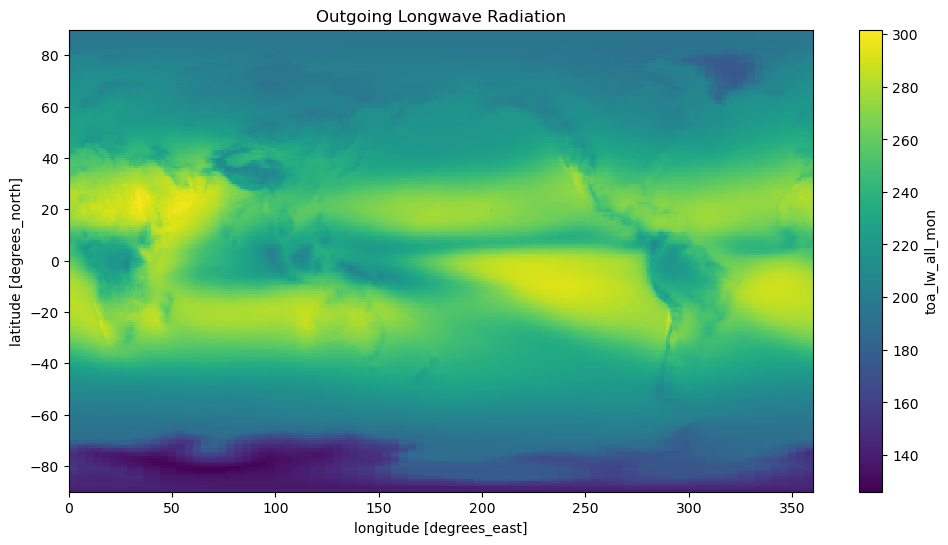

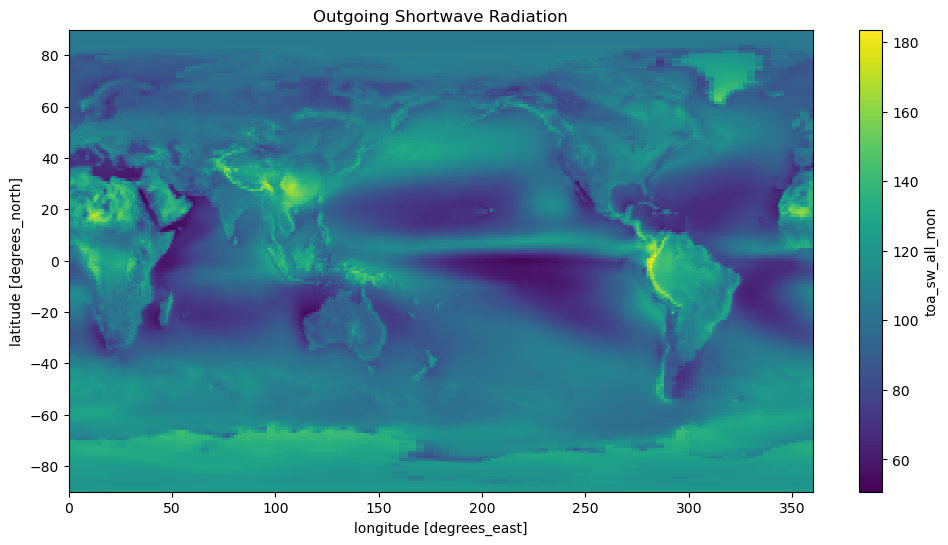

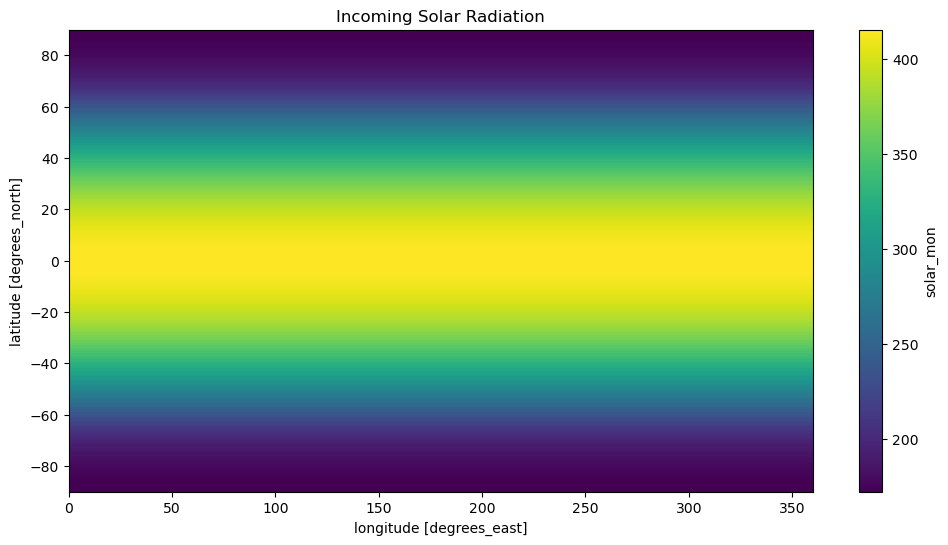

In [6]:
ds_mean['toa_lw_all_mon'].plot()
plt.title("Outgoing Longwave Radiation")
plt.show()

ds_mean['toa_sw_all_mon'].plot()
plt.title("Outgoing Shortwave Radiation")
plt.show()

ds_mean['solar_mon'].plot()
plt.title("Incoming Solar Radiation")
plt.show()

### 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux

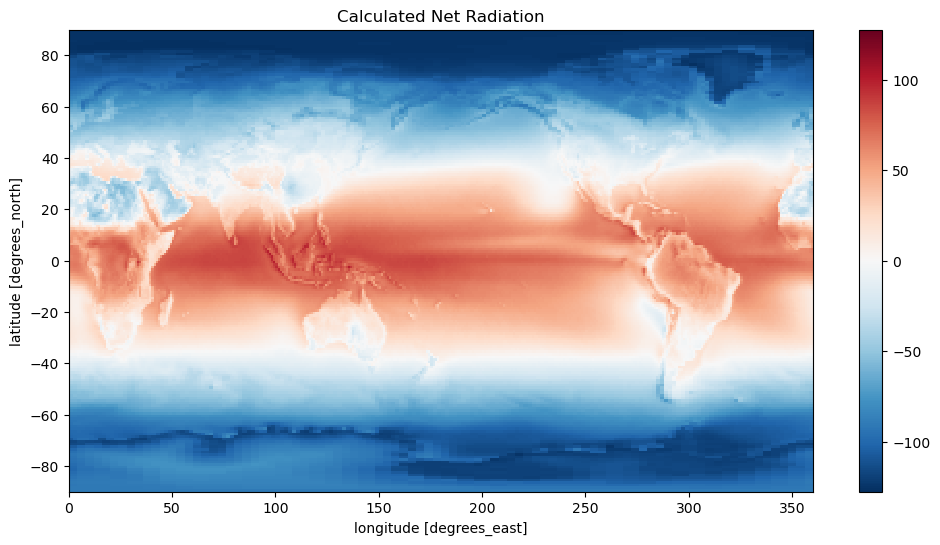

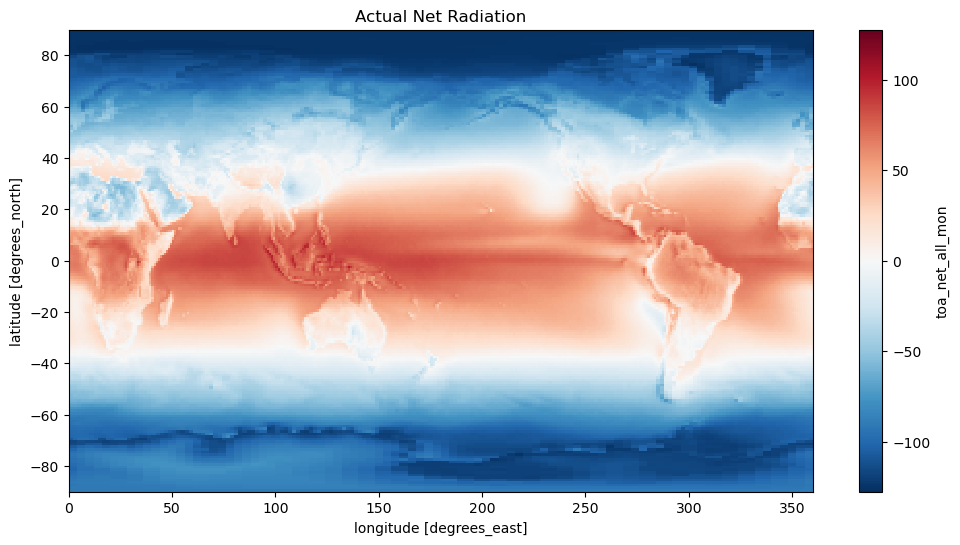

In [7]:
net_calc = (
    ds_mean['solar_mon']
    - ds_mean['toa_sw_all_mon']
    - ds_mean['toa_lw_all_mon']
)

net_calc.plot()
plt.title("Calculated Net Radiation")
plt.show()

ds_mean['toa_net_all_mon'].plot()
plt.title("Actual Net Radiation")
plt.show()

## 3) Mean and weighted mean

### 3.1) Calculate the global (unweighted) mean of TOA net radiation

In [8]:
ds_mean.toa_net_all_mon.mean(dim=('lat', 'lon'))

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(-28.729012, dtype=float32)

The unweighted global mean is biased because each grid point is treated equally, even though grid cells at high latitudes represent much smaller surface area than grid cells near the equator. Therefore, a simple arithmetic mean over lat and lon does not produce a true global mean.

### 3.2) Create a `weight` array proportional to cos(λ)

In [9]:
weights = np.cos(ds.lat * np.pi/180)
weights

<xarray.DataArray 'lat' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361933, 0.06104851, 0.07845908,
       0.09584564, 0.11320312, 0.13052613, 0.14780948, 0.16504757,
       0.18223551, 0.19936782, 0.21643965, 0.2334453 , 0.25037998,
       0.26723838, 0.28401524, 0.30070582, 0.31730458, 0.3338068 ,
       0.35020736, 0.3665012 , 0.38268346, 0.398749  , 0.4146933 ,
       0.43051106, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.50753826, 0.5224985 , 0.5372996 , 0.551937  , 0.5664062 ,
       0.58070296, 0.59482276, 0.60876137, 0.6225146 , 0.6360782 ,
       0.64944804, 0.66262   , 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.80385685, 0.8141155 ,
       0.8241262 , 0.8338858 , 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.8788171 , 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.8788171 , 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.8338858 , 0.8241262 ,
       0.8141155 , 0.80385685, 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262   , 0.64944804,
       0.6360782 , 0.6225146 , 0.60876137, 0.59482276, 0.58070296,
       0.5664062 , 0.551937  , 0.5372996 , 0.5224985 , 0.50753826,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051106,
       0.4146933 , 0.398749  , 0.38268346, 0.3665012 , 0.35020736,
       0.3338068 , 0.31730458, 0.30070582, 0.28401524, 0.26723838,
       0.25037998, 0.2334453 , 0.21643965, 0.19936782, 0.18223551,
       0.16504757, 0.14780948, 0.13052613, 0.11320312, 0.09584564,
       0.07845908, 0.06104851, 0.04361933, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

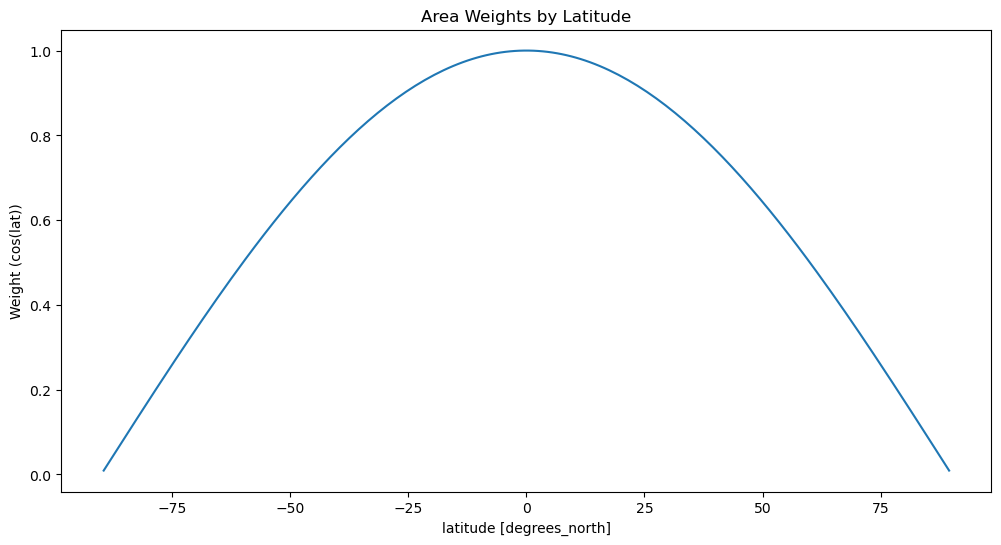

In [10]:
weights.plot()
plt.title('Area Weights by Latitude')
plt.ylabel('Weight (cos(lat))')
plt.show()

### 3.3) Redo your global mean TOA net radiation calculation with this weight factor

In [11]:
ds_mean.toa_net_all_mon.weighted(weights).mean(dim=('lat', 'lon'))

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.878088, dtype=float32)

Yes. The weighted global mean net TOA radiation is about 0.88 W m$^{-2}$, which is small and positive, consistent with Earth’s present-day energy imbalance. This means Earth is absorbing slightly more energy than it emits. The result is therefore physically reasonable, although it should still be interpreted as an approximate estimate from this dataset.

### 3.4) Now that you have a `weight` factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [12]:
for var in ['solar_mon', 'toa_sw_all_mon', 'toa_lw_all_mon', 'toa_net_all_mon']:
    val = ds[var].weighted(weights).mean().values
    print(f"{var} : {val} W/m²")

solar_mon : 340.28326416015625 W/m²
toa_sw_all_mon : 99.13804626464844 W/m²
toa_lw_all_mon : 240.26690673828125 W/m²
toa_net_all_mon : 0.8780879378318787 W/m²


The weighted global means closely match the expected global energy budget. The incoming solar radiation is about 340.3 W m$^{-2}$, the reflected shortwave radiation is about 99.1 W m$^{-2}$, and the outgoing longwave radiation is about 240.3 W m$^{-2}$. These values are consistent with the expected global energy budget and help confirm that the weighted calculation is working correctly.

## 4) Meridional Heat Transport Calculation

### 4.1) calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it

In [13]:
R = 6_371_000.0

d_lambda = np.deg2rad(1.0)
d_phi = np.deg2rad(1.0)

ones = xr.ones_like(ds.toa_net_all_mon.isel(time=0))

pixel_area = (R**2) * np.cos(np.deg2rad(ds.lat)) * ones * d_lambda * d_phi
pixel_area.name = 'pixel_area'
pixel_area.attrs['units'] = 'm^2'

total_area = pixel_area.sum().item()
sphere_area = 4 * np.pi * R**2

print(f"Total pixel area = {total_area:.6e} m^2")
print(f"Sphere area      = {sphere_area:.6e} m^2")
print(f"Ratio            = {total_area / sphere_area:.8f}")

Total pixel area = 5.100710e+14 m^2
Sphere area      = 5.100645e+14 m^2
Ratio            = 1.00001271


### 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band

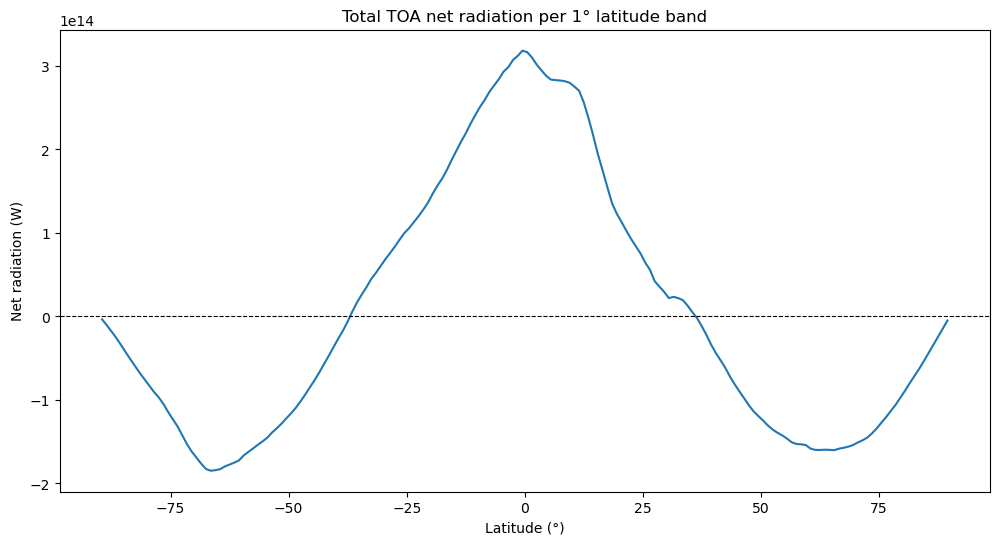

In [14]:
net_rad_band = (ds_mean.toa_net_all_mon * pixel_area).sum(dim='lon')

net_rad_band.plot()
plt.xlabel('Latitude (°)')
plt.ylabel('Net radiation (W)')
plt.title('Total TOA net radiation per 1° latitude band')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')

### 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude

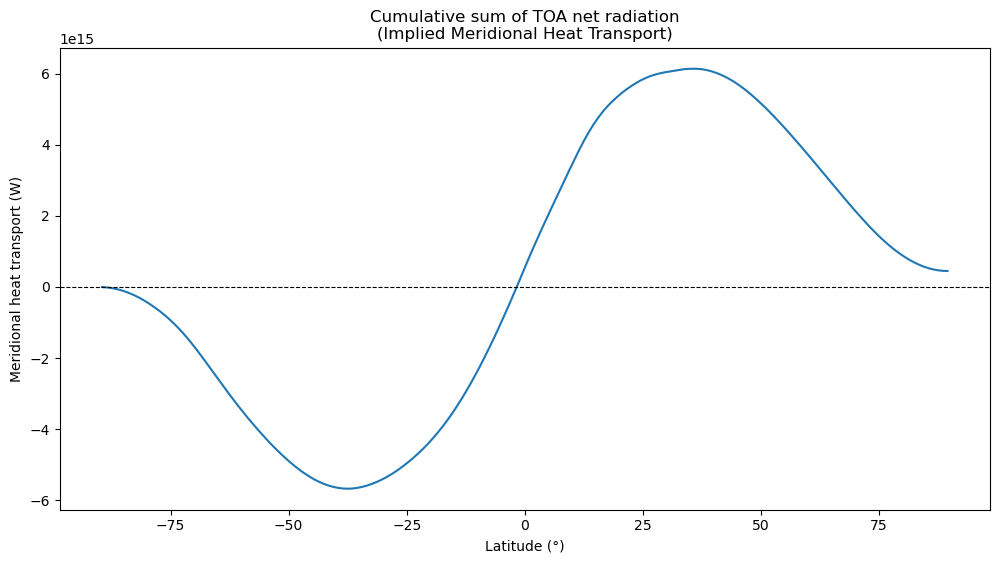

In [15]:
net_rad_cumsum = net_rad_band.cumsum(dim='lat')

net_rad_cumsum.plot()
plt.xlabel('Latitude (°)')
plt.ylabel('Meridional heat transport (W)')
plt.title('Cumulative sum of TOA net radiation\n(Implied Meridional Heat Transport)')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')

## 5) Making Maps with Cartopy

### 5.2) Antarctic Sea Ice

In [16]:
import xarray as xr
import pooch
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')

In [17]:
ds_ice

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:                             Comiso, J. C., and F. Nishio. 200...
    program:                                NOAA Climate Data Record Program
    cdr_variable:                           seaice_conc_cdr
    software_version_id:                    git@bitbucket.org:nsidc/seaice_cd...
    Metadata_Link:                          https://nsidc.org/api/dataset/met...
    product_version:                        v03r01
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    proj_units:                             meters

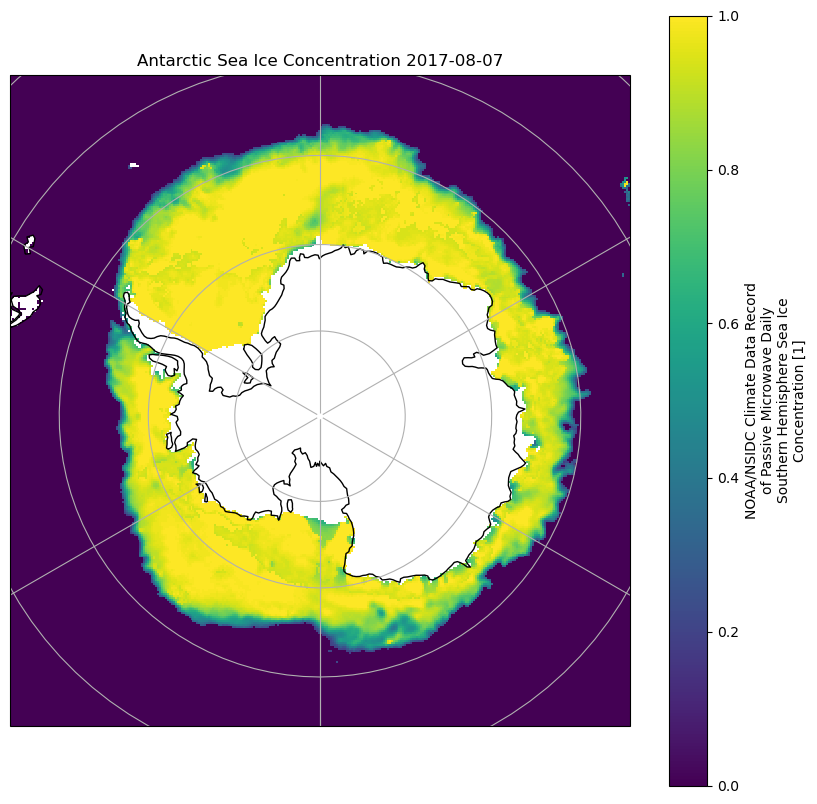

In [18]:
import cartopy.crs as ccrs

proj = ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude=-70)

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=proj)

ice = ds_ice['seaice_conc_cdr'].isel(time=0)
ice = ice.where((ice >= 0) & (ice <= 1))

ice.plot(ax=ax, transform=proj, x='xgrid', y='ygrid')

ax.coastlines()
ax.gridlines()
ax.set_title('Antarctic Sea Ice Concentration 2017-08-07')
plt.show()

### 5.3) Global USGS Earthquakes


In [19]:
import pandas as pd

url = 'http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv'
df = pd.read_csv(url, parse_dates=['time'])
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


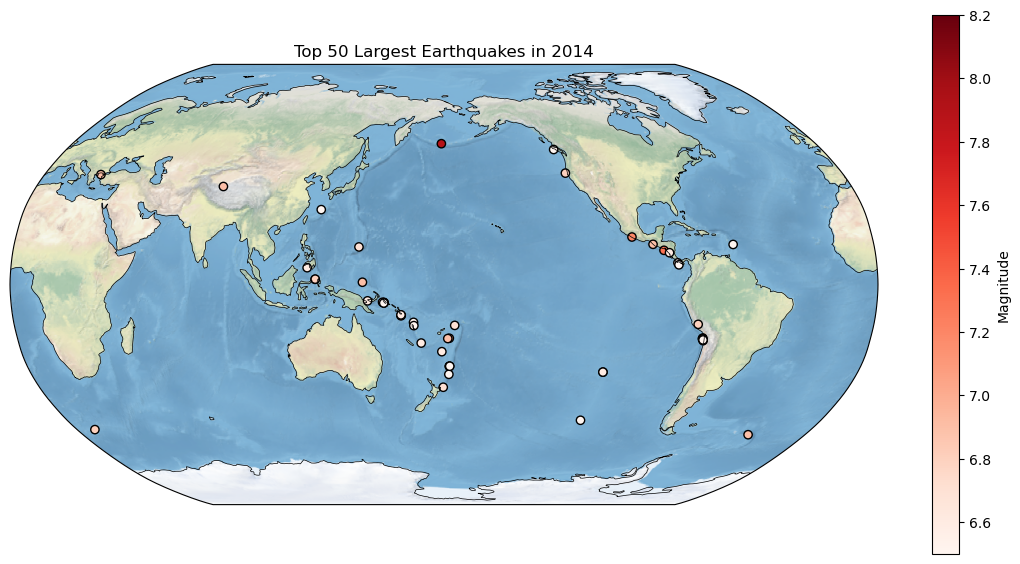

In [20]:
import cartopy.crs as ccrs

earthquake = df.nlargest(50, 'mag')

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.stock_img()
ax.coastlines(linewidth=0.5)

sc = ax.scatter(earthquake['longitude'], earthquake['latitude'],c=earthquake['mag'], cmap='Reds', edgecolor='k',transform=ccrs.PlateCarree())

plt.colorbar(sc, label='Magnitude')
plt.title('Top 50 Largest Earthquakes in 2014')
plt.show()